<a href="https://colab.research.google.com/github/Uday-SR/CNN/blob/main/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_dirs = {
    "Original": "/content/drive/MyDrive/Datasets/RealWaste_final/RealWaste_Original",
    "Noisy": "/content/drive/MyDrive/Datasets/RealWaste_final/RealWaste_Noisy",
    "Blurred": "/content/drive/MyDrive/Datasets/RealWaste_final/RealWaste_Blurred",
    "Dark": "/content/drive/MyDrive/Datasets/RealWaste_final/RealWaste_Dark",
    "Bright": "/content/drive/MyDrive/Datasets/RealWaste_final/RealWaste_Bright"
}

os.listdir(data_dirs['Original'])

['train', 'validation', 'test']

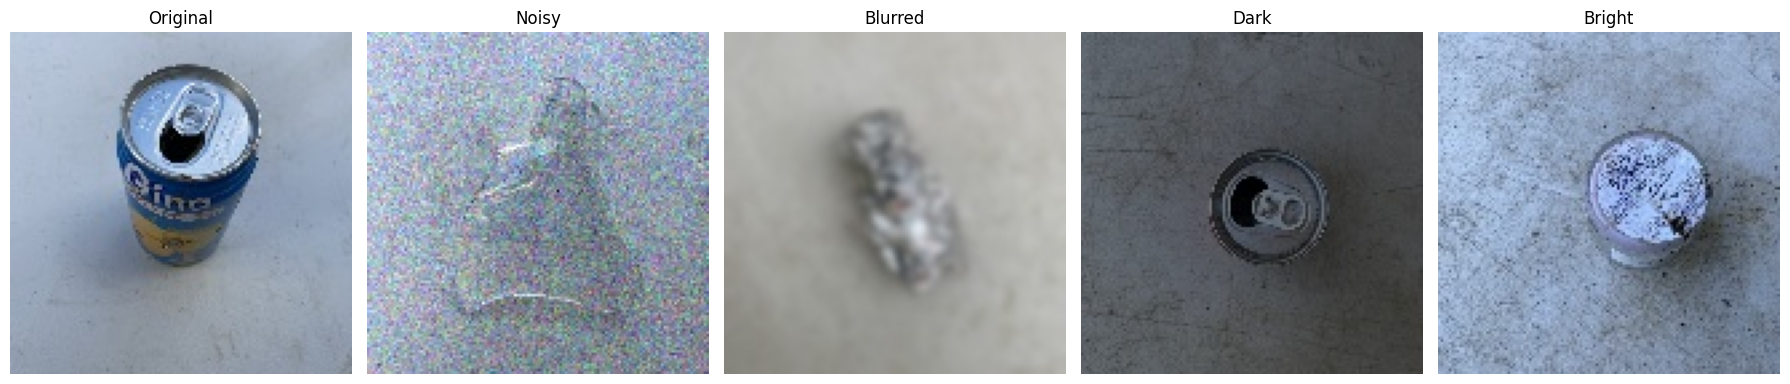

In [7]:
# Processed datasets image

plt.figure(figsize=(18,5))

for i, (dataset_name, dataset_path) in enumerate(data_dirs.items()):

    # Get all image paths
    image_paths = []

    train_split = os.path.join(dataset_path, 'train')

    for class_name in os.listdir(train_split):

        class_path = os.path.join(train_split, class_name)

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, img_name))

    # Choose one random image
    random_image = random.choice(image_paths)

    # Read image
    img = cv2.imread(random_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display
    plt.subplot(1, len(data_dirs), i+1)
    plt.imshow(img)
    plt.title(dataset_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
# Load Dataset function

IMG_SIZE = (224,224)
BATCH_SIZE = 32

def load_dataset(dataset_path):

    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(dataset_path, 'train'),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(dataset_path, 'validation'),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(dataset_path, 'test'),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_ds, val_ds, test_ds


In [9]:
def preprocess(image, label):
    return preprocess_input(image), label

In [10]:
def create_model():

    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    model = Sequential([

        base_model,

        GlobalAveragePooling2D(),

        Dense(512, activation="relu"),

        Dropout(0.5),

        Dense(256, activation="relu"),

        Dropout(0.3),

        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [26]:
# Train Model

In [12]:
results = {}

AUTOTUNE = tf.data.AUTOTUNE

for name, path in data_dirs.items():

    print(f"\nTraining on {name} dataset")

    train_ds, val_ds, test_ds = load_dataset(path)

    train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.prefetch(AUTOTUNE)

    val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)

    test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)

    model = create_model()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5
    )

    loss, acc = model.evaluate(test_ds)

    results[name] = acc


Training on Original dataset
Found 1441 files belonging to 4 classes.
Found 308 files belonging to 4 classes.
Found 312 files belonging to 4 classes.
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.6433 - loss: 1.2248 - val_accuracy: 0.8052 - val_loss: 0.4383
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.8154 - loss: 0.5240 - val_accuracy: 0.8734 - val_loss: 0.3412
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.8765 - loss: 0.3709 - val_accuracy: 0.8896 - val_loss: 0.2902
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - accuracy: 0.8904 - loss: 0.3144 - val_accuracy: 0.8994 - val_loss: 0.2640
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - accuracy: 0.9278 - loss: 0.1969 - val_accuracy: 0.8961 - val_loss: 0.2876
10/10 ━━━━━━━━━━━━━━━━━━━━ 109s 11s/step - accuracy: 0.9006 - loss: 0.2638

Training on Noisy dataset
Found 1441 files belonging to 4 classes.
Found 308 files belonging to 4 classes.
Found 312 files belonging to

In [13]:
for dataset, accuracy in results.items():
    print(dataset, ":", accuracy)

Original : 0.9006410241127014
Noisy : 0.875
Blurred : 0.9262820482254028
Dark : 0.9102563858032227
Bright : 0.9134615659713745


In [24]:
train_loss, train_acc = model.evaluate(train_ds)

val_loss, val_acc = model.evaluate(val_ds)

test_loss, test_acc = model.evaluate(test_ds)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)
print("Validation Accuracy:", val_acc)




46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.9813 - loss: 0.0724
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.8994 - loss: 0.2766
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.9135 - loss: 0.2691
Training Accuracy: 0.9812630414962769
Testing Accuracy: 0.9134615659713745
Validation Accuracy: 0.899350643157959


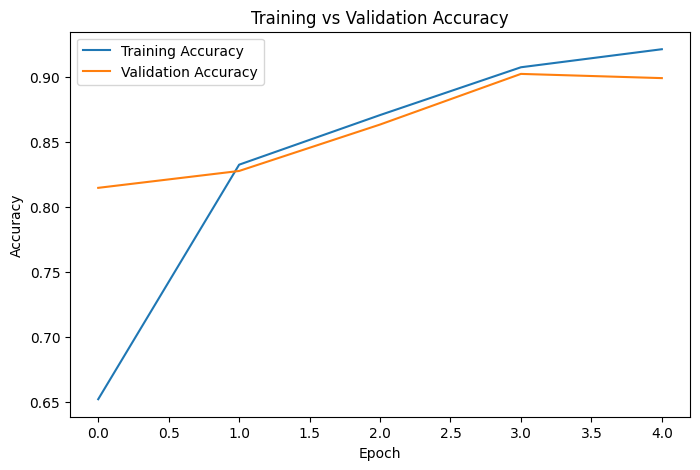

In [25]:
# Training vs Validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()